In [11]:
# Install required libraries
!pip install easyocr opencv-python openpyxl -q
import pandas as pd
import cv2
import numpy as np
import os
import easyocr
from google.colab import files
import openpyxl
from datetime import datetime

In [12]:
from google.colab.patches import cv2_imshow

In [13]:
def preprocess_image(image_data):
    # Convert uploaded file bytes to numpy array
    nparr = np.frombuffer(image_data, np.uint8)
    image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    if image is None:
        raise ValueError("Failed to load image")

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize image to make text larger
    scale_factor = 5
    gray = cv2.resize(gray, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LINEAR)

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    #_, thresh = cv2.threshold(blurred, 128, 255, cv2.THRESH_BINARY)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations to clean up noise
    kernel = np.ones((1, 1), np.uint8)

    # Apply morphological opening to remove small noise
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # Apply erosion to remove noise
    thresh = cv2.erode(thresh, kernel, iterations=1)


    return thresh,image

Please upload your image files (PNG, JPG, JPEG supported):


Saving 9.jpg to 9.jpg
Saving plate-1530536506.jpg to plate-1530536506.jpg
Saving s-l400.jpg to s-l400.jpg
Saving wankld.jpg to wankld.jpg

Processing: 9.jpg


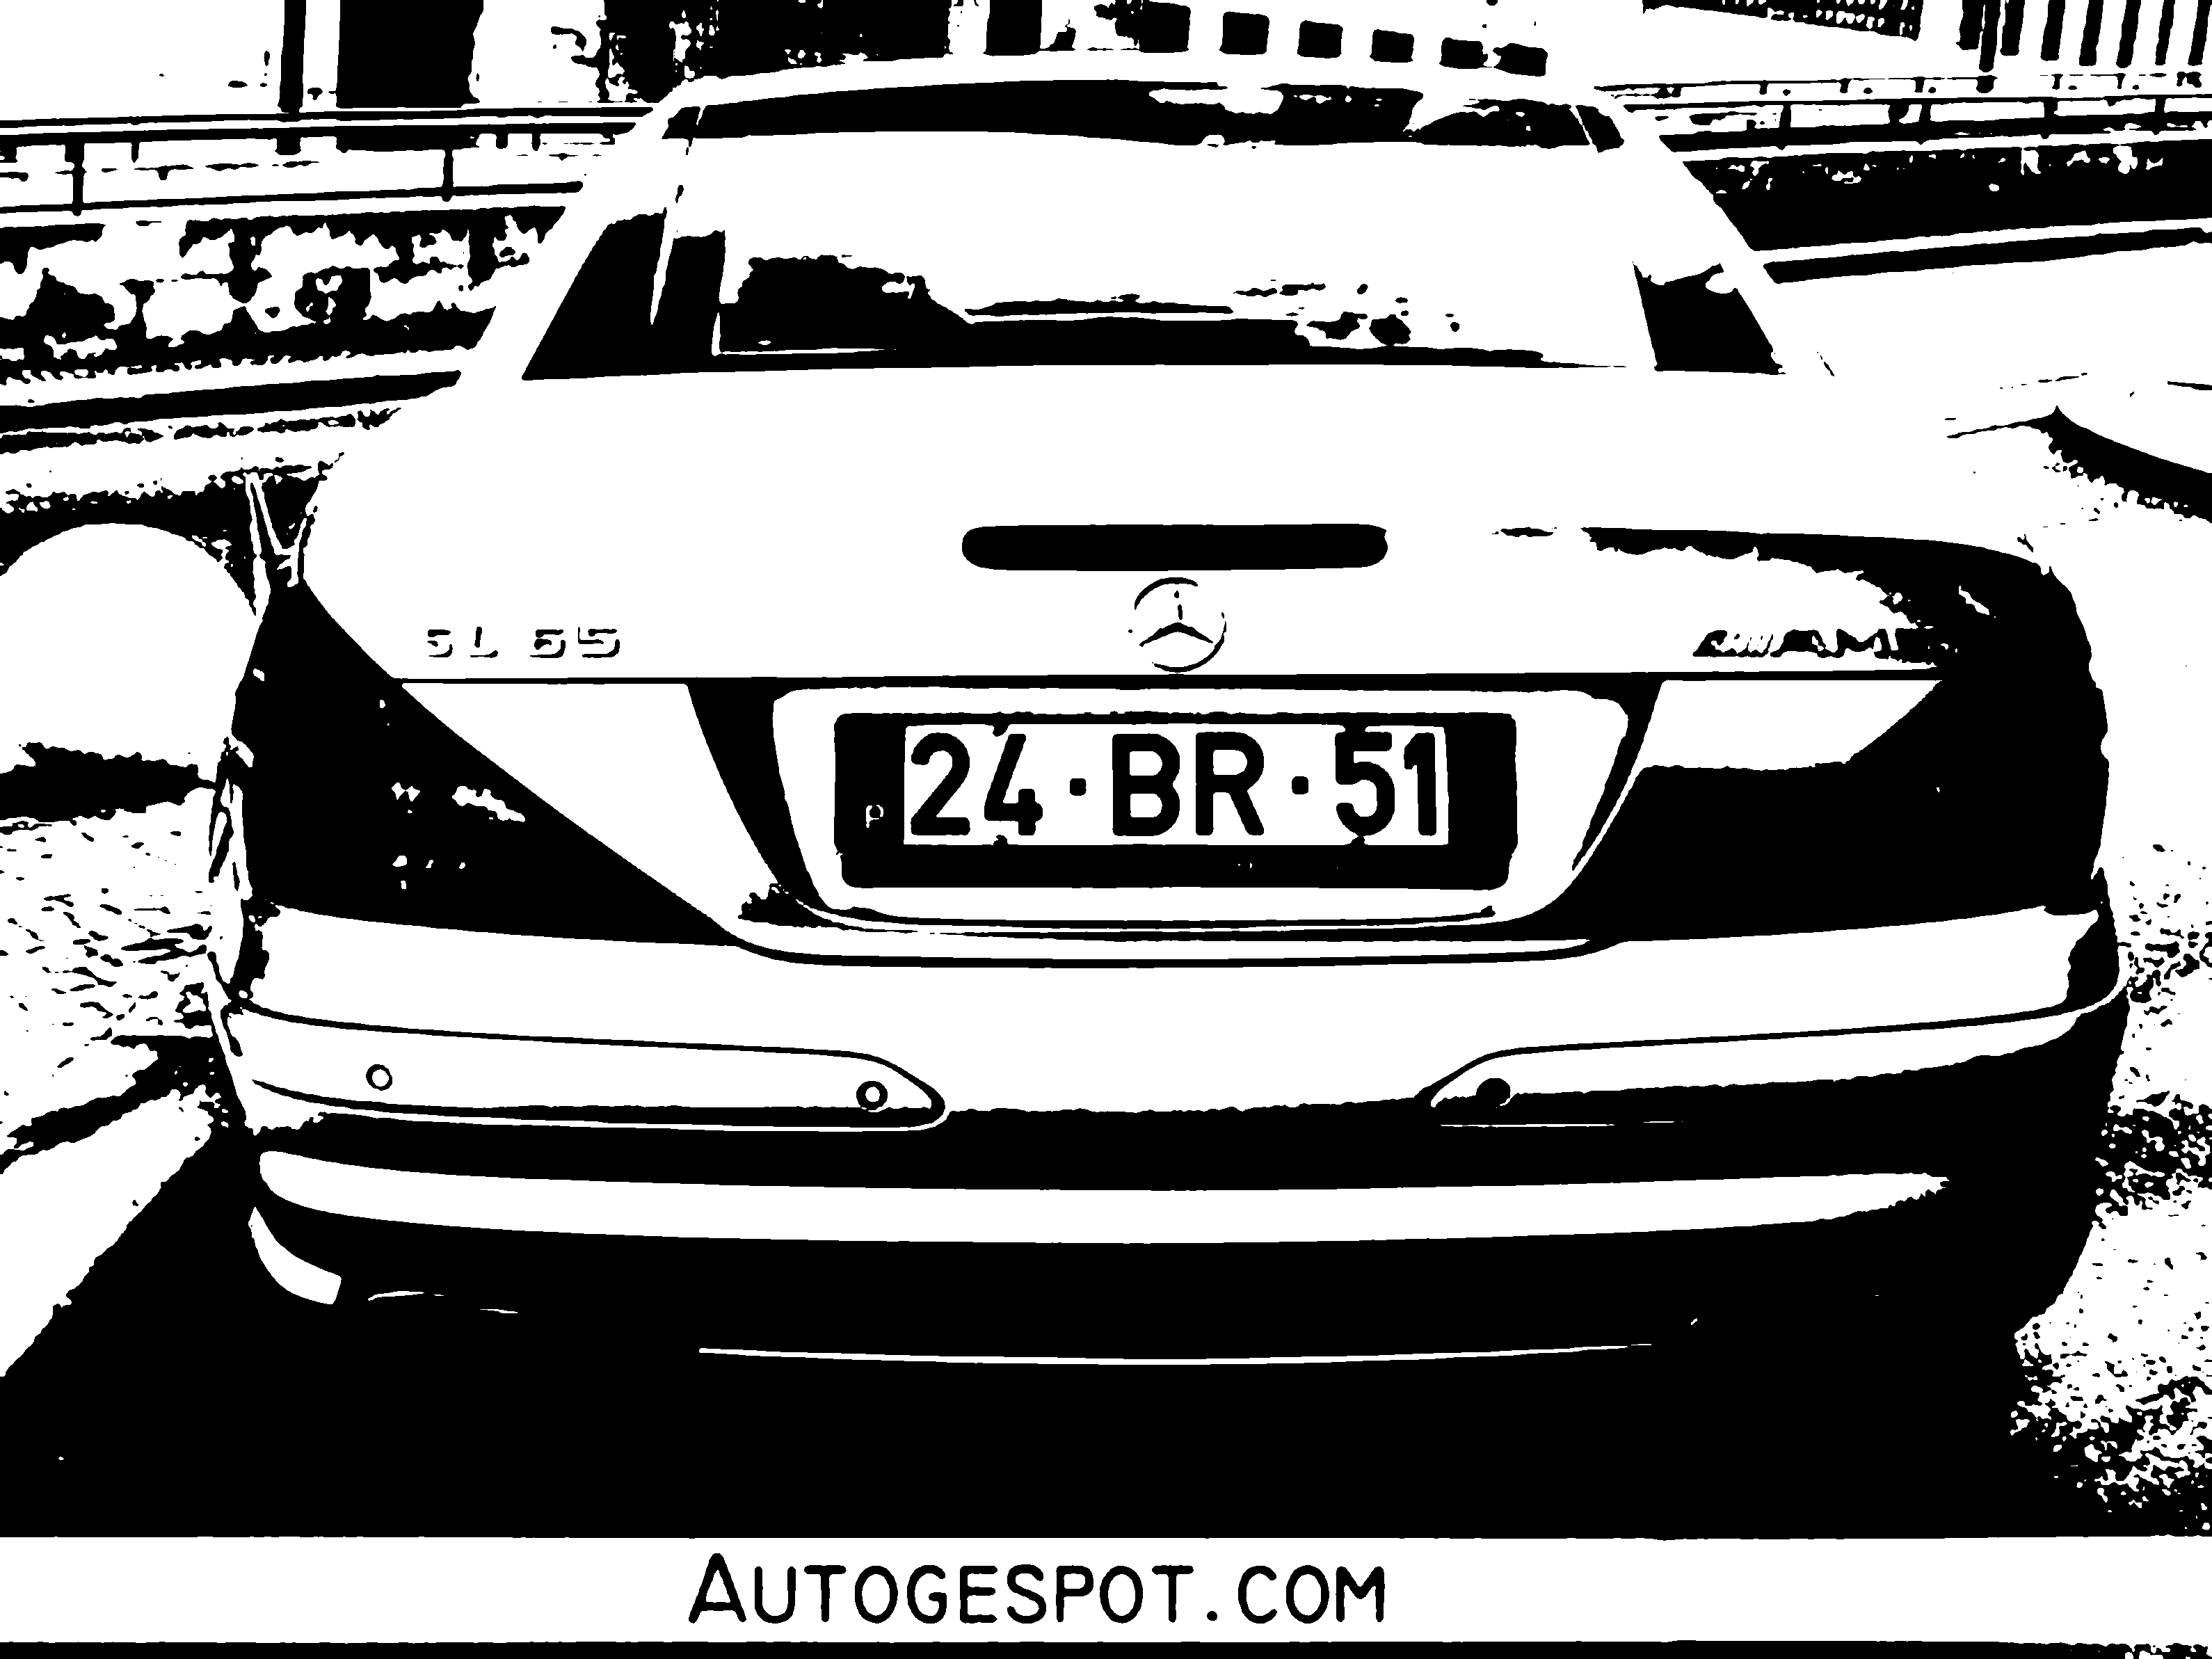

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracted text from 9.jpg: 3 5 L 55 V 24BR51 AUTOGESPOT.COM...

Processing: plate-1530536506.jpg


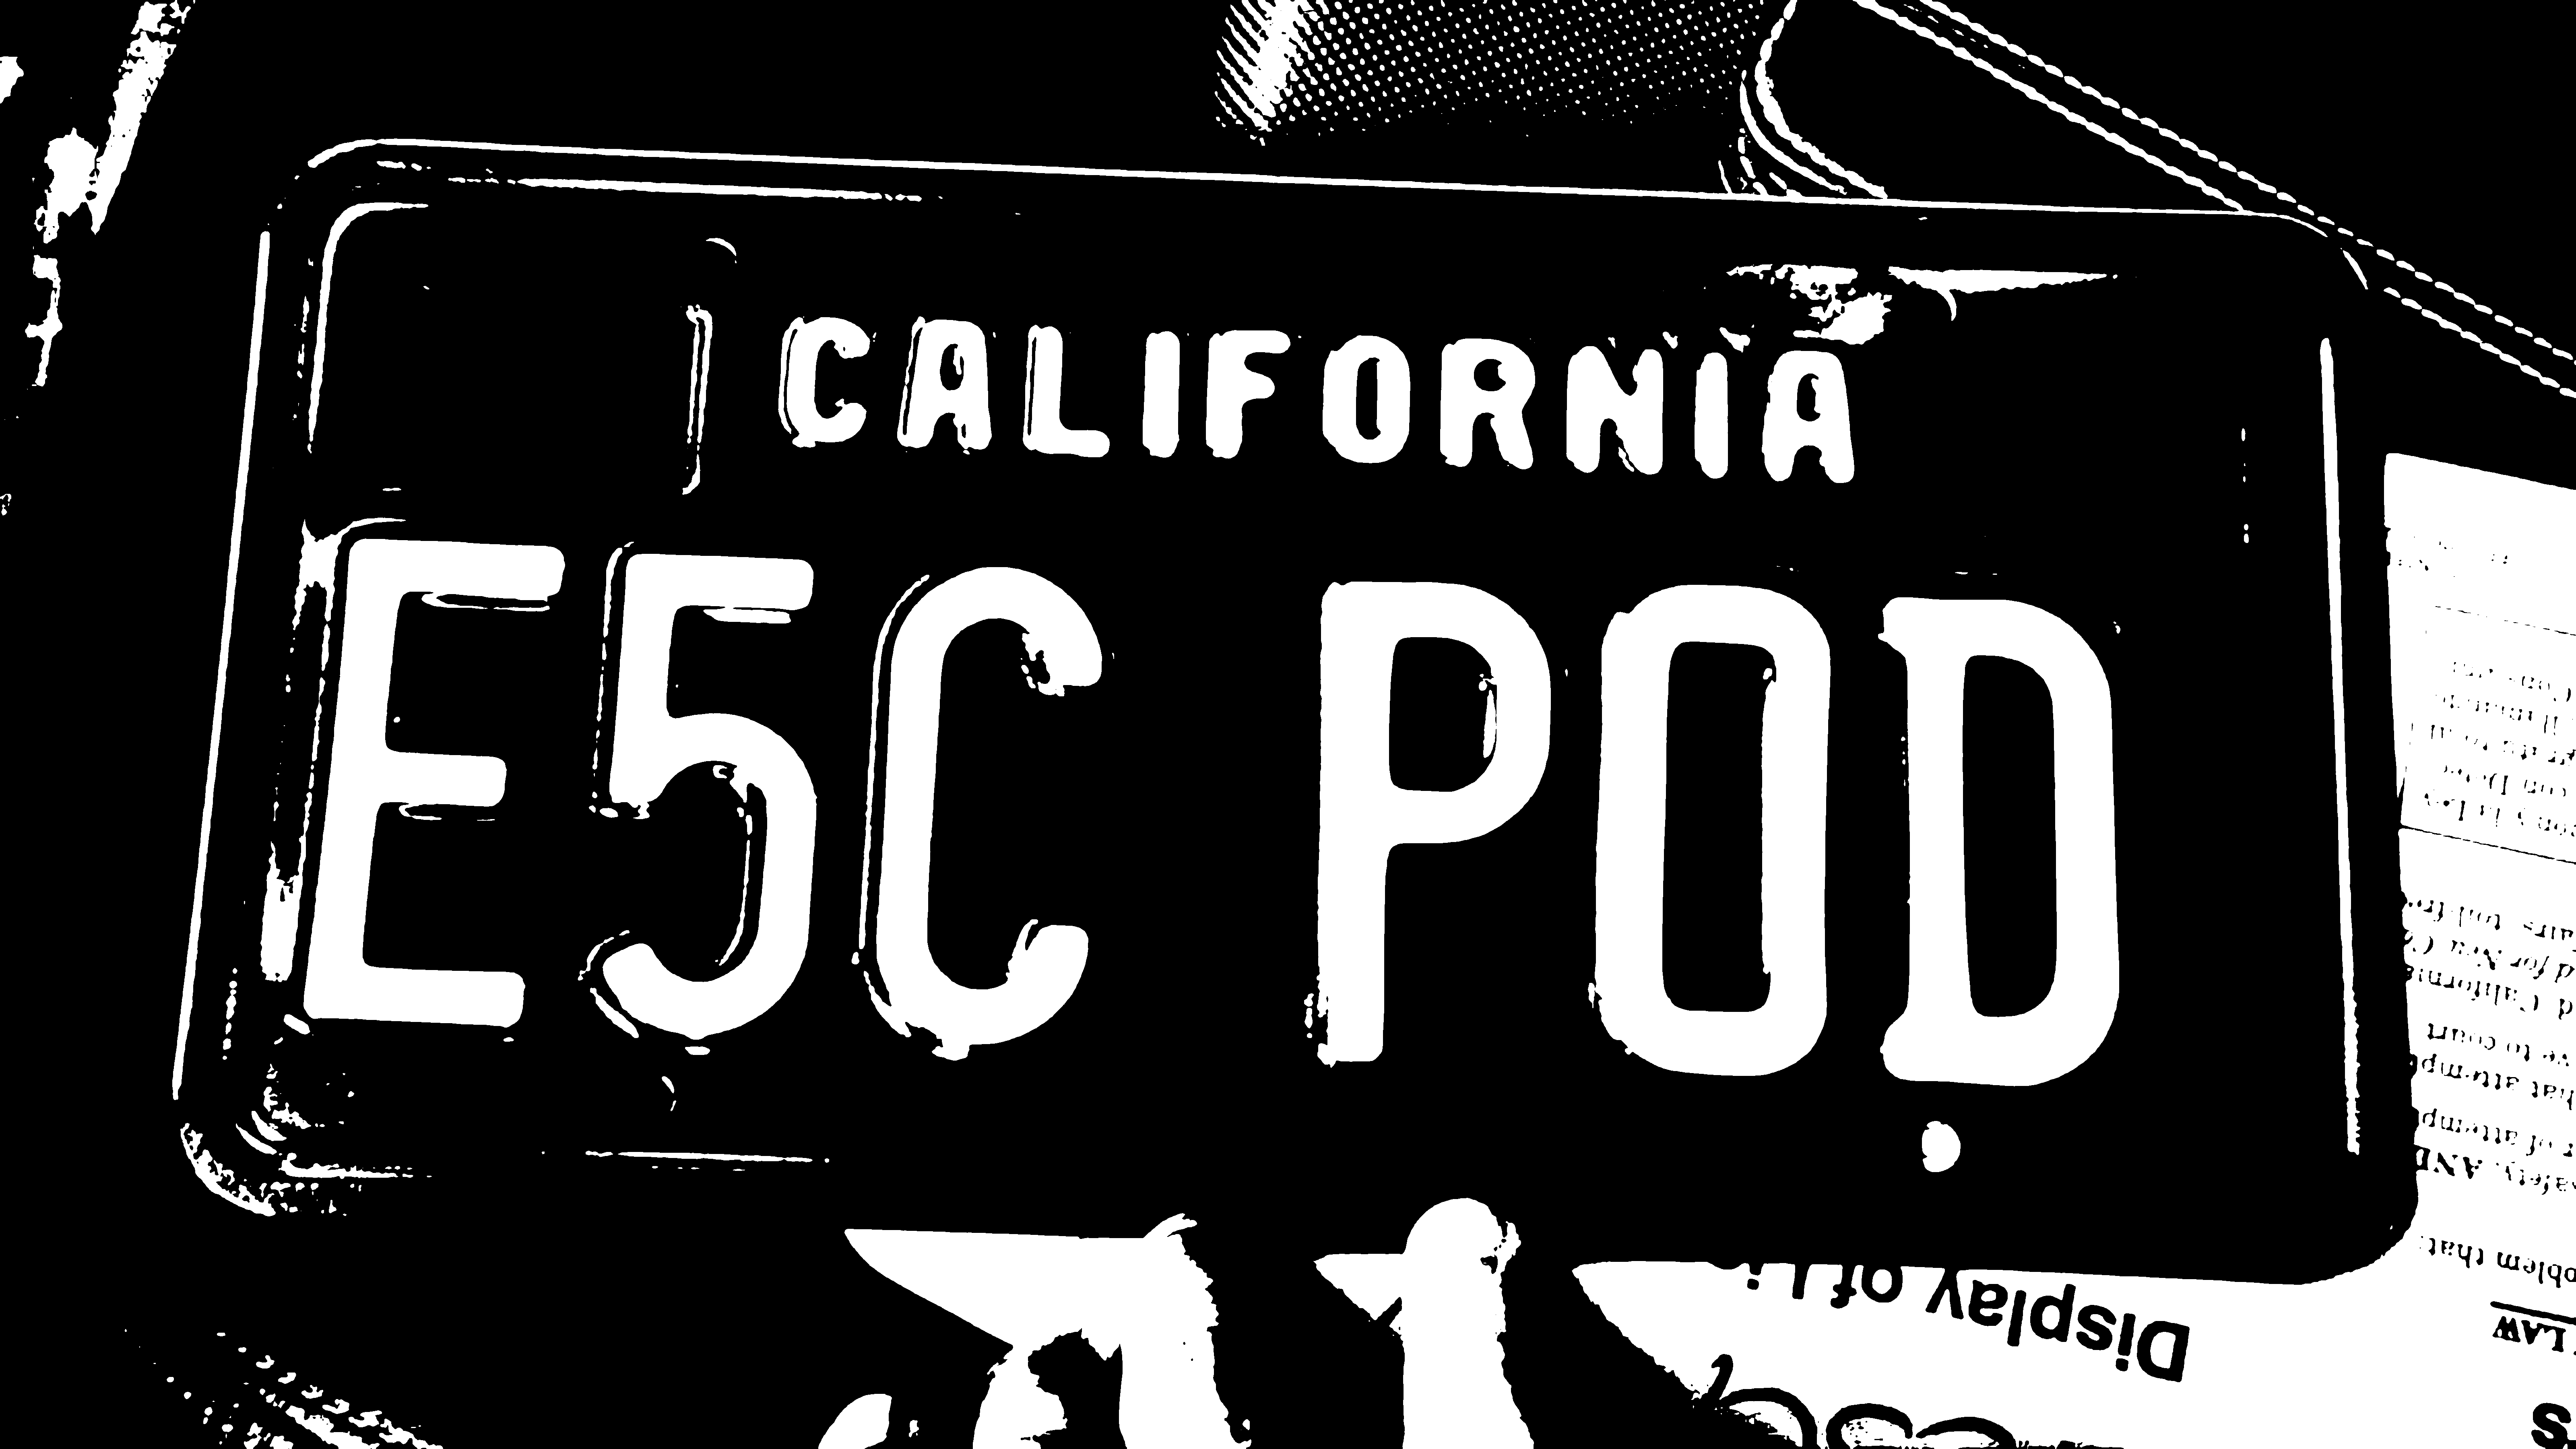

Extracted text from plate-1530536506.jpg: caLIformia 5 POD "'1 X 2: Jo 3 C F5L ["] 4Im "} p ...

Processing: s-l400.jpg


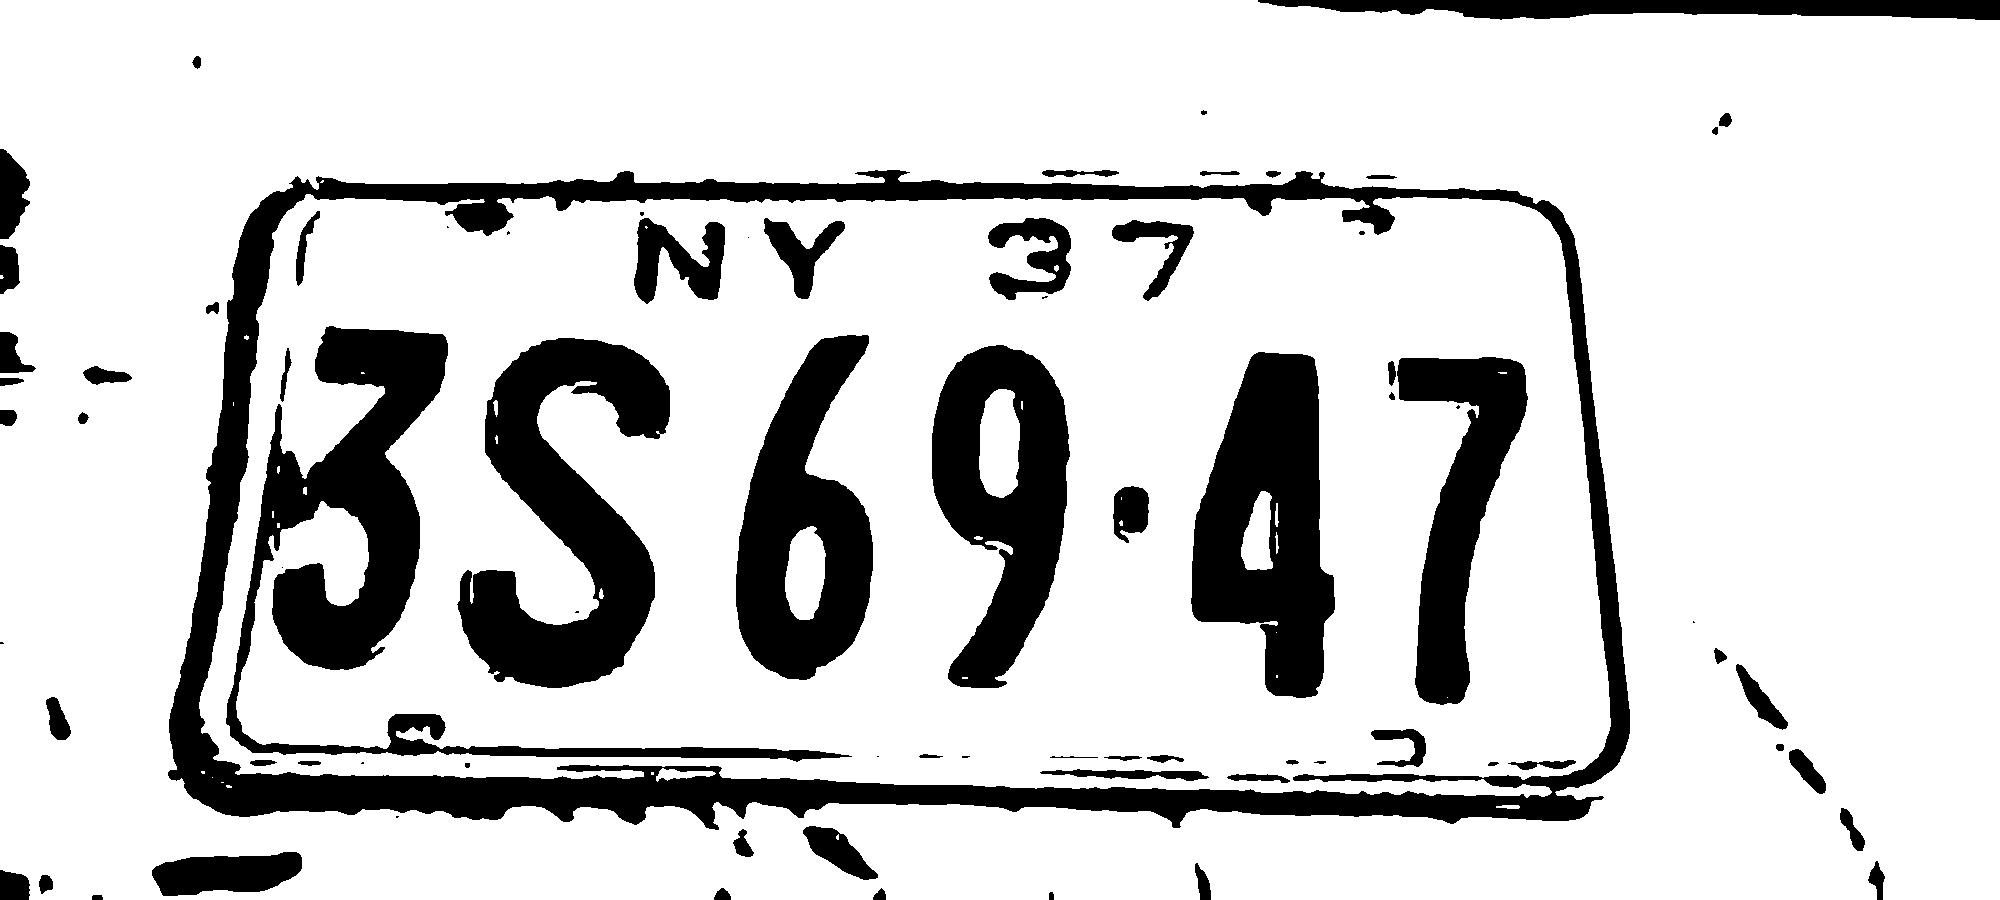

Extracted text from s-l400.jpg: NY 27 3S69+47 3...

Processing: wankld.jpg


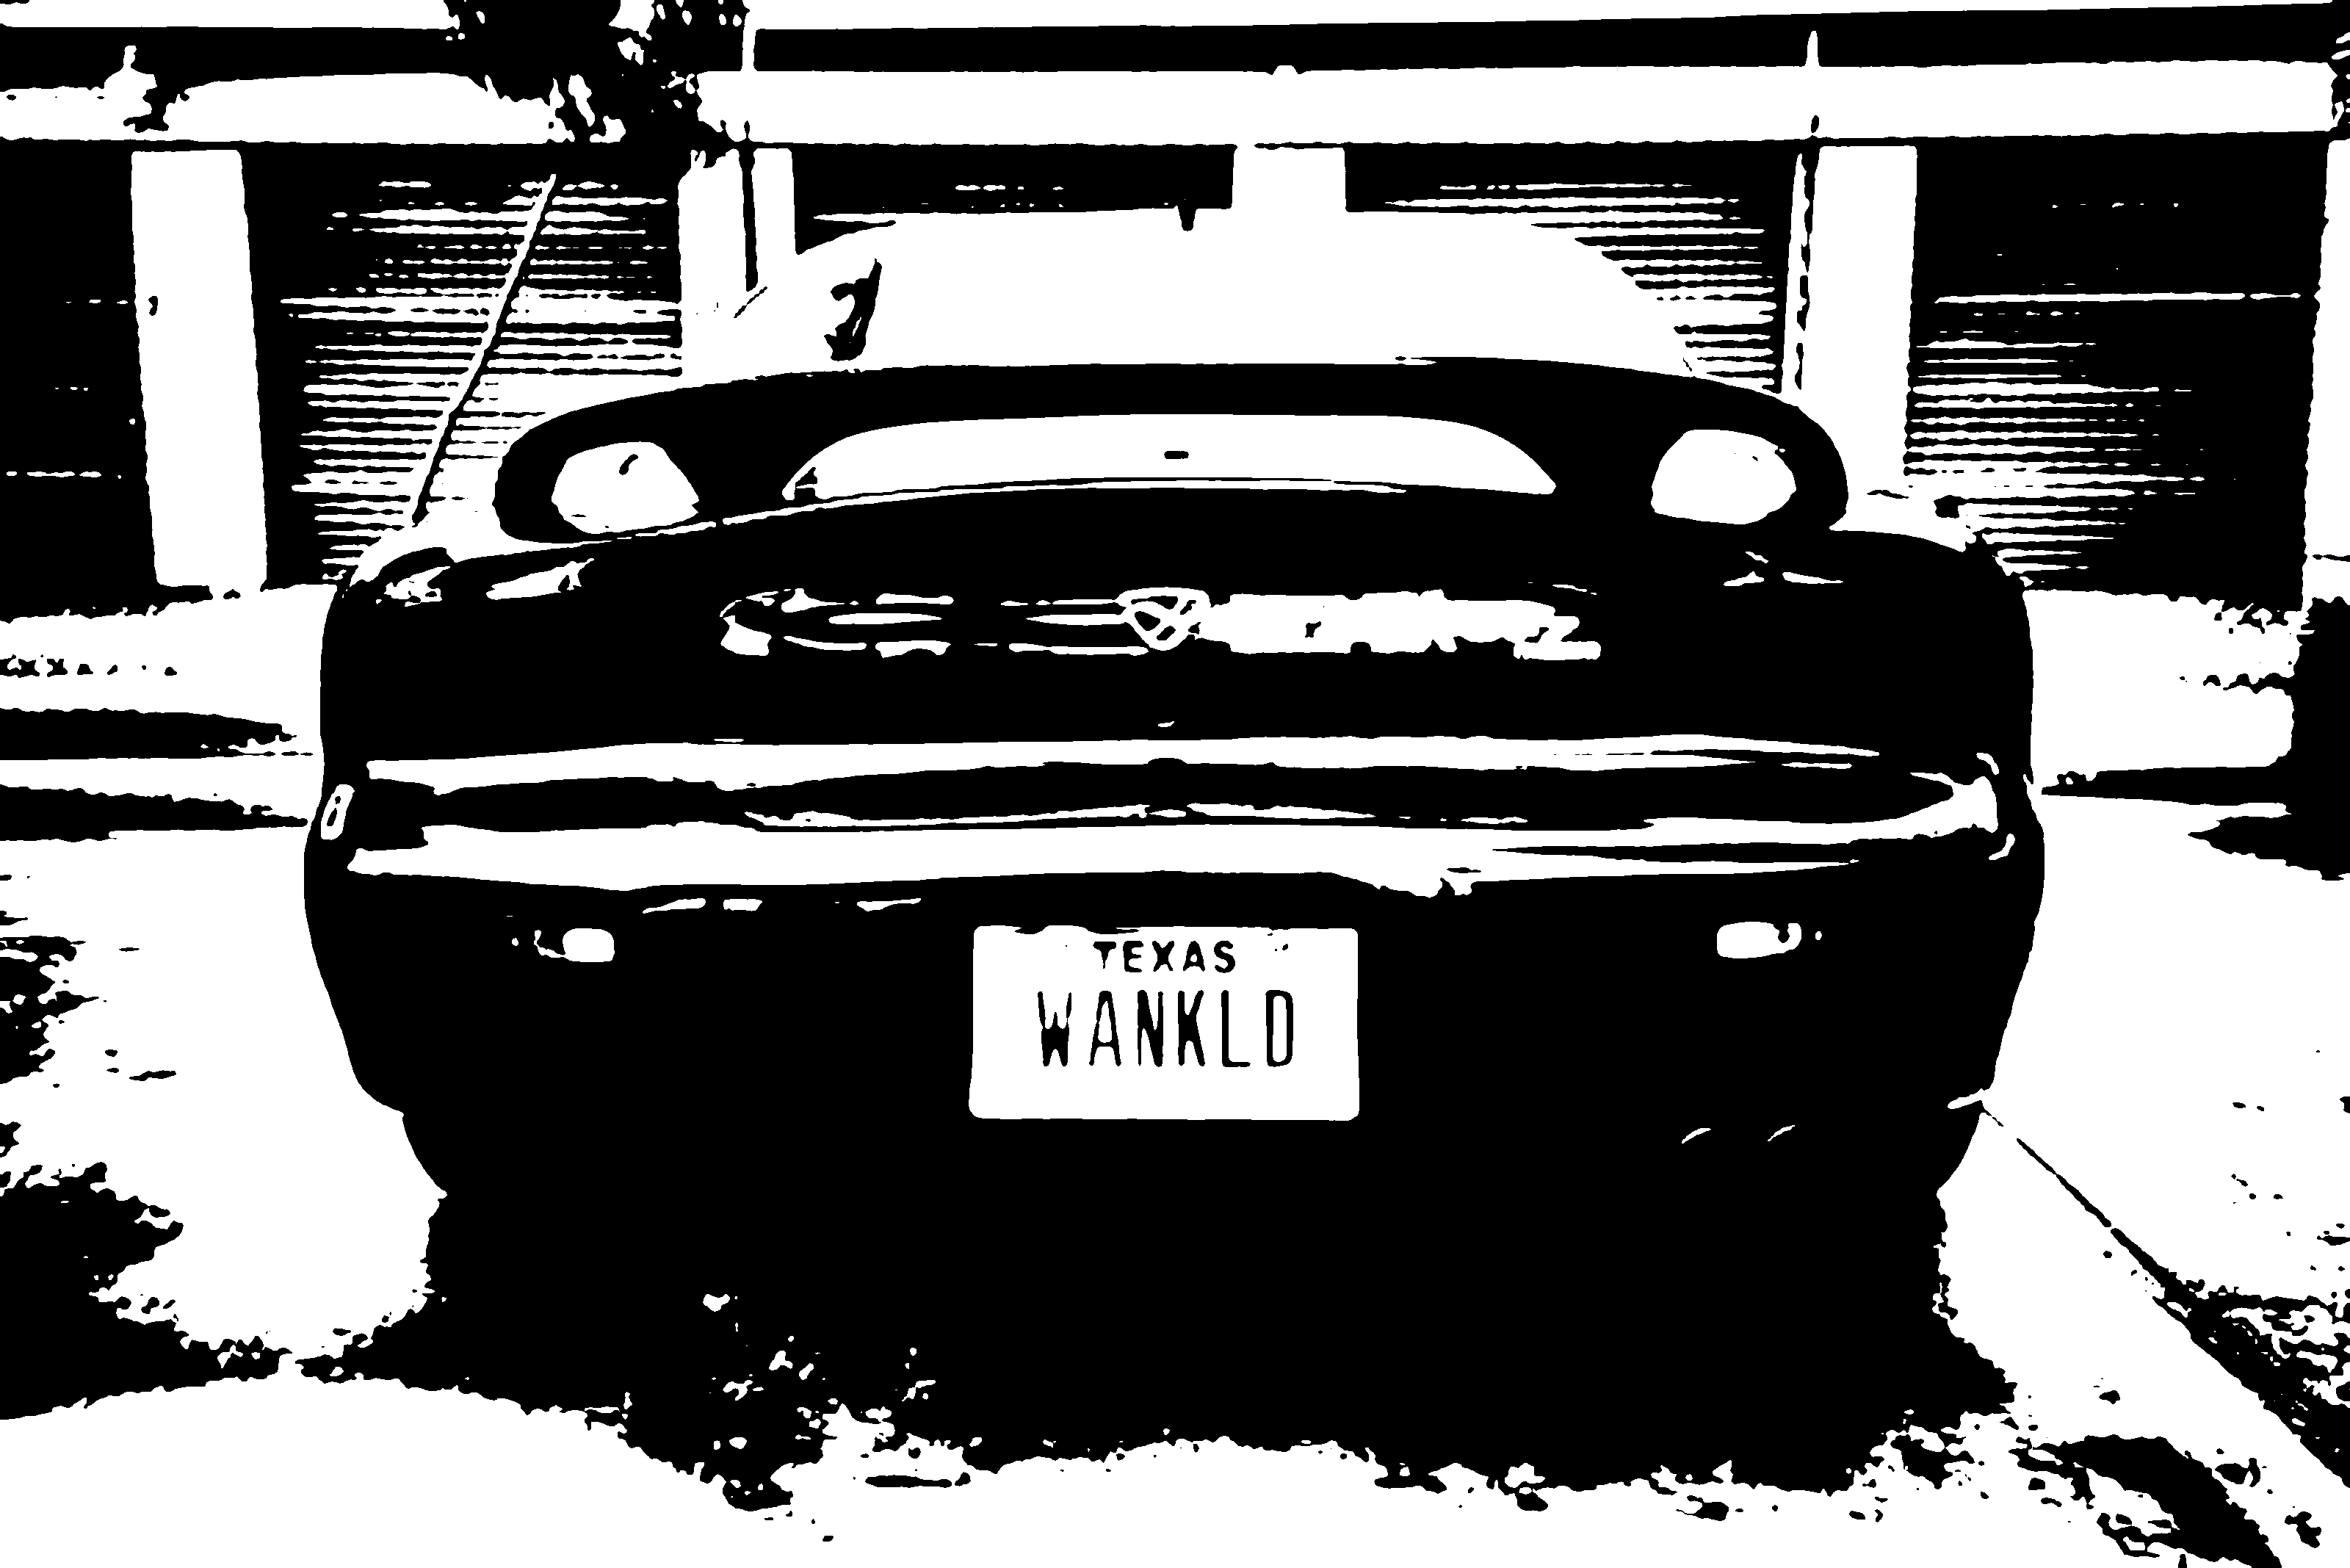

Extracted text from wankld.jpg: 7 2  4x TEXAS wankld...

Results saved to ocr_results_numberplate.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
def perform_ocr(image_data):
    try:
        # Preprocess the image
        processed_img, original_img = preprocess_image(image_data)
        cv2_imshow(processed_img)

        # Save temporary processed image
        temp_path = "/tmp/temp_processed.png"
        cv2.imwrite(temp_path, processed_img)

        # Perform OCR with EasyOCR
        reader = easyocr.Reader(['en'],gpu=True)
        result = reader.readtext(processed_img, detail=0)
        os.remove(temp_path)

        # Check if any text was detected
        if not result:
            print("Warning: No text detected in the image")
            return "No text detected"

        # Join the detected text (EasyOCR returns a list of strings)
        text = " ".join(result)
        return text.strip()

    except Exception as e:
        print(f"Error during OCR processing: {str(e)}")
        return f"Error: {str(e)}"



def save_to_excel(results):
    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "OCR Results"
    ws['A1'] = "Image Name"
    ws['B1'] = "Extracted Text"

    for row, (img_name, text) in enumerate(results.items(), start=2):
        ws[f'A{row}'] = img_name
        ws[f'B{row}'] = text

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_file = f"ocr_results_{timestamp}.xlsx"
    wb.save(output_file)
    return output_file

def main():
    print("Please upload your image files (PNG, JPG, JPEG supported):")
    uploaded = files.upload()

    if not uploaded:
        print("No files uploaded. Please try again.")
        return

    ocr_results = {}

    for filename, content in uploaded.items():
      if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
          print(f"\nProcessing: {filename}")
          text = perform_ocr(content)
          ocr_results[filename] = text
          print(f"Extracted text from {filename}: {text[:50]}...")

    if ocr_results:
    # Convert dictionary to DataFrame
      df = pd.DataFrame(list(ocr_results.items()), columns=['Image Name', 'Extracted Text'])

    # Define output file name
      output_file = "ocr_results_numberplate.xlsx"

    # Save DataFrame to Excel
      df.to_excel(output_file, index=False)

      print(f"\nResults saved to {output_file}")

    # Download file (if using Google Colab)
      files.download(output_file)
    else:
      print("No valid images processed.")

if __name__ == "__main__":
    main()

In [17]:
!pip install pillow
from PIL import Image, ImageEnhance

In [18]:
def preprocess_image(image_data):
    # Convert uploaded file bytes to numpy array
    """Preprocess image using OpenCV to enhance OCR accuracy."""
    nparr = np.frombuffer(image_data, np.uint8)
    image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    if image is None:
        raise ValueError("Failed to load image")

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # Apply Median blur to reduce noise
    blurred = cv2.medianBlur(gray,5)

    # Convert processed grayscale back to a color image
    processed_cv = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

    # Convert to PIL image
    processed_image = Image.fromarray(processed_cv)

    # Increase contrast
    contrast_enhancer = ImageEnhance.Contrast(processed_image)
    processed_image = contrast_enhancer.enhance(3.0)

    # Increase sharpness
    sharpness_enhancer = ImageEnhance.Sharpness(processed_image)
    processed_image = sharpness_enhancer.enhance(3.0)
    processed_cv_final = np.array(processed_image)

    return processed_cv_final, image

Please upload your image files (PNG, JPG, JPEG supported):


Saving 20240513_090125000_iOS_1.jpg to 20240513_090125000_iOS_1 (2).jpg
Saving 20240518_035419000_iOS_1.jpg to 20240518_035419000_iOS_1 (1).jpg
Saving 20240518_035928000_iOS_1.jpg to 20240518_035928000_iOS_1 (1).jpg
Saving 20240601_081648000_iOS 1_1.jpg to 20240601_081648000_iOS 1_1 (1).jpg

Processing: 20240513_090125000_iOS_1 (2).jpg


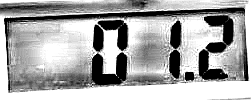

Extracted text from 20240513_090125000_iOS_1 (2).jpg: 82...

Processing: 20240518_035419000_iOS_1 (1).jpg


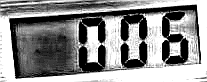

Extracted text from 20240518_035419000_iOS_1 (1).jpg: #ws]...

Processing: 20240518_035928000_iOS_1 (1).jpg


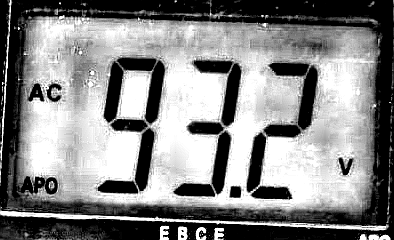

Extracted text from 20240518_035928000_iOS_1 (1).jpg: Ac Apo 932 68 @ F...

Processing: 20240601_081648000_iOS 1_1 (1).jpg


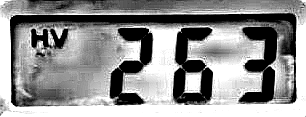

Extracted text from 20240601_081648000_iOS 1_1 (1).jpg: Hv 263...

Results saved to ocr_results_voltagemeter.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
def perform_ocr(image_data):
    try:
        # Preprocess the image
        processed_img, original_img = preprocess_image(image_data)
        cv2_imshow(processed_img)

        # Save temporary processed image
        temp_path = "/tmp/temp_processed.png"
        cv2.imwrite(temp_path, processed_img)

        # Perform OCR with EasyOCR
        reader = easyocr.Reader(['en'],gpu=True)  # Initialize EasyOCR for English
        result = reader.readtext(processed_img, detail=0)  # detail=0 returns only the text

        # Clean up temporary file
        os.remove(temp_path)

        # Check if any text was detected
        if not result:
            print("Warning: No text detected in the image")
            return "No text detected"

        # Join the detected text (EasyOCR returns a list of strings)
        text = " ".join(result)
        return text.strip()

    except Exception as e:
        print(f"Error during OCR processing: {str(e)}")
        return f"Error: {str(e)}"



def save_to_excel(results):
    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "OCR Results"
    ws['A1'] = "Image Name"
    ws['B1'] = "Extracted Text"

    for row, (img_name, text) in enumerate(results.items(), start=2):
        ws[f'A{row}'] = img_name
        ws[f'B{row}'] = text

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_file = f"ocr_results_{timestamp}.xlsx"
    wb.save(output_file)
    return output_file

def main():
    print("Please upload your image files (PNG, JPG, JPEG supported):")
    uploaded = files.upload()

    if not uploaded:
        print("No files uploaded. Please try again.")
        return

    ocr_results = {}

    for filename, content in uploaded.items():
      if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
          print(f"\nProcessing: {filename}")
          text = perform_ocr(content)  # Assuming this function exists
          ocr_results[filename] = text
          print(f"Extracted text from {filename}: {text[:50]}...")

    if ocr_results:
    # Convert dictionary to DataFrame
      df = pd.DataFrame(list(ocr_results.items()), columns=['Image Name', 'Extracted Text'])

    # Define output file name
      output_file = "ocr_results_voltagemeter.xlsx"

    # Save DataFrame to Excel
      df.to_excel(output_file, index=False)

      print(f"\nResults saved to {output_file}")

    # Download file (if using Google Colab)
      files.download(output_file)
    else:
      print("No valid images processed.")

if __name__ == "__main__":
    main()